# Angol Premier League Mérkőzések Elemzése és Prediktív Modellezése

## Téma: Labdarúgó mérkőzések statisztikáinak elemzése (Önálló Laboratórium)

**Készítette:** Németh Máté

**Adatforrás:** Football-Data.co.uk (https://www.football-data.co.uk/)

**Adathalmaz:** Angol Premier League mérkőzések 2015/16 - 2024/25 szezonok (E0.csv)

**Cél:** A Premier League mérkőzéseinek feltáró adatelemzése (EDA), a mérkőzések kimenetelét befolyásoló tényezők (pl. forma, hazai pálya, lövések) azonosítása, hipotézisek tesztelése, és prediktív modellek építése.

## Tartalomjegyzék

1. [Problémakör és Célkitűzés Bemutatása](#section-1)
2. [Kezdeti Hipotézisek Megfogalmazása](#section-2)
3. [Adathalmaz Bemutatása](#section-3)
4. [Adatgyűjtés és Adathalmaz Beolvasása (Adattisztítás)](#section-4)
5. [Kezdeti Adatvizualizációk](#section-5)
6. [Összefüggések Feltárása - Hipotézisek Tesztelése](#section-6)
7. [Feature Engineering (Változók Kialakítása)](#section-7)
8. [Új Összefüggések Felfedezése](#section-8)
9. [Prediktív Modellezés](#section-9)
10. [Következtetések és Konklúzió](#section-10)

## <a id="section-1"></a>1. Problémakör és Célkitűzés Bemutatása

### Problémafelvetés
A modern labdarúgásban óriási szerepe van az adatalapú döntéshozatalnak. Egy-egy mérkőzés kimenetele látszólag a véletlenen is múlhat, de az adatokban olyan összefüggések és tendenciák rejtőzhetnek, melyeket a fogadóirodák, profi elemzők nap mint nap használnak. A kihívás az, hogy a rendelkezésre álló nyers, sokrétű meccsstatisztikából (lövések, szögletek, sárga lapok, stb.) képes vagyok-e hasznos következtetéseket és megbízható predikciókat levonni a mérkőzések végkimenetelére vonatkozóan.

### Célkitűzéseim
1. **Adatbázis építés**: A hivatalos forrásból származó (football-data.co.uk) szezonális CSV fájlok transzformálása és összefűzése egy nagy adatbázissá.
2. **Leíró elemzés**: A Premier League elmúlt tíz évéből származó trendek feltárása (hazai pálya előnye, gólok eloszlása szezonszinten).
3. **Új változók generálása (Feature Engineering)**: Az egyszerű meccsstatisztikákból olyan komplex mutatókat számolni, mint például a csapatok "formája" (az utolsó N meccsen szerzett pontok).
4. **Hipotézisek validálása**: Konkrét, életszerű futballanalitikai állítások felállítása és adatalapú bizonyítása vagy cáfolása (EDA során).
5. **Predikció**: Egy alapvető Machine Learning modell (pl. Logisztikus Regresszió vagy Random Forest) beállítása, ami a múltbeli meccsek alapján megpróbálja előrejelezni a kimenetelt (H, D, A).

## <a id="section-2"></a>2. Kezdeti Hipotézisek Megfogalmazása

Az adatgyűjtés és feldolgozás előtt a következő **alapvető feltételezéseket** fogalmaztam meg, melyekkel ellenőrizhetem az adathalmaz helyességét és az iparági "alapigazságokat". 

*Megjegyzés: Ezek csupán a kiindulási pontok. Célom, hogy ezen alapvető hipotézisek tesztelése (EDA) után **új, komplexebb, és kevéssé egyértelmű összefüggéseket fedezzek fel**, melyekre aztán a prediktív modellezést építhetem.*

### **H1: A "Hazai pálya előnye" egyértelmű, de időben és helyzetben (COVID) változó**
Feltételezem, hogy a hazai csapatok szignifikánsan több meccset nyernek meg (kb. 45-50% körül), míg a vendégsiker 30% körül mozog. Továbbá feltételezem, hogy ez a "hazai bástya" jelentősen csökkent a 2020/21-es szezonban, amikor a koronavírus miatt a mérkőzések nagyrészt zárt kapuk (nézők) nélkül zajlottak.

### **H2: A "Kaput eltaláló lövések" (Shots on Target) sokkal jobban korrelálnak a lőtt gólokkal, mint az "Összes lövés" (Total Shots) száma**
Egyes csapatok sokszor próbálkoznak távolról, ami növeli a lövések számát, de nem vezet feltétlenül több gólhoz. A kaput eltaláló lövések száma sokkal minőségibb indikátora egy csapat offenzív erejének.

### **H3: A fogadóirodák szorzói (Odds) matematikai alapú, pontos indikátorai az erőviszonyoknak**
Feltételezem, hogy a fogadóirodák (pl. Bet365) esélyszámításai (legkisebb odds = legmagasabb esély) kiemelten nagy korrelációt mutatnak a tényleges végeredménnyel, ezért önmagukban rendkívül erős változók lennének bármilyen gépi tanulási modell számára.

## <a id="section-3"></a>3. Adathalmaz Bemutatása

A projekt során az angol Premier League elmúlt tíz évének mérkőzésadatait használom (2015/16-os szezontól napjainkig). 

**Forrás:** [Football-Data.co.uk](https://www.football-data.co.uk/)
Ez az adatbázis az egyik legnépszerűbb és leginkább megbízható nyílt forrás a futballelemzők számára, mivel nem csak a végeredményeket, hanem a mérkőzések alapvető statisztikáit és az európai fogadóirodák oddsait is tartalmazza.

**A nyers adatok legfontosabb oszlopai:**

**Alapadatok:**
- `Div`: Bajnokság azonosítója (E0 = Premier League)
- `Date`: Mérkőzés dátuma
- `HomeTeam` / `AwayTeam`: Hazai / Vendég csapat neve
- `Referee`: Játékvezető neve

**Gólok és eredmények:**
- `FTHG` (Full Time Home Goals): Hazai gólok száma
- `FTAG` (Full Time Away Goals): Vendég gólok száma
- `FTR` (Full Time Result): Végeredmény (H=Hazai, D=Döntetlen, A=Vendég)
- `HTHG` / `HTAG` / `HTR`: Félidei eredmények és kimenetel

**Mérkőzésstatisztikák:**
- `HS` / `AS` (Home/Away Shots): Összes lövés
- `HST` / `AST` (Home/Away Shots on Target): Kaput eltaláló lövések
- `HC` / `AC` (Home/Away Corners): Szögletek száma
- `HF` / `AF` (Home/Away Fouls): Szabálytalanságok száma
- `HY` / `AY` (Home/Away Yellow cards): Sárga lapok
- `HR` / `AR` (Home/Away Red cards): Piros lapok

**Fogadóirodák szorzói (Odds):**
- `B365H` / `B365D` / `B365A`: A Bet365 fogadóiroda szorzói a hazai győzelemre, döntetlenre és vendég győzelemre.
- *Ezeken kívül több más iroda (pl. William Hill, Pinnacle) oddsa is szerepel a fájlban, de csak a legnagyobbakat fogom használni referenciaként.*

## <a id="section-4"></a>4. Adatgyűjtés és Adathalmaz Beolvasása

Ebben a részben automatizálva letöltöm az Angol Premier League (E0.csv) adatait az elmúlt közel 10 szezonra a `football-data.co.uk` weboldalról. Ez a megközelítés lehetővé teszi, hogy később más ligákra is könnyen kiterjesszem a kódot.

In [34]:
import os
import urllib.request
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Hozzuk létre a 'data' mappát, ha még nem létezik
mappa_nev = 'data'
if not os.path.exists(mappa_nev):
    os.makedirs(mappa_nev)
    print(f"A '{mappa_nev}' mappa sikeresen létrehozva!")
else:
    print(f"A '{mappa_nev}' mappa már létezik.")

# 2. Definiáljuk a szezonokat (15/16-tól 24/25-ig)
szezonok = ['1516', '1617', '1718', '1819', '1920', '2021', '2122', '2223', '2324', '2425']

base_url = "https://www.football-data.co.uk/mmz4281/"
liga_kod = "E0.csv"

print("Létező fájlok ellenőrzése / Letöltés megkezdése...\n")

for szezon in szezonok:
    url = f"{base_url}{szezon}/{liga_kod}"
    fajl_utvonal = f"{mappa_nev}/E0_{szezon}.csv"
    
    # Csak akkor töltjük le, ha még nem létezik, így nem terheljük feleslegesen a szervert
    if not os.path.exists(fajl_utvonal):
        try:
            urllib.request.urlretrieve(url, fajl_utvonal)
            print(f"Sikeresen letöltve: {szezon} szezon -> {fajl_utvonal}")
        except Exception as e:
            print(f"Hiba a {szezon} szezon letöltésekor az alábbi URL-ről: {url}\nHiba: {e}")
    else:
        print(f"Már létezik: {szezon} szezon -> {fajl_utvonal} (Kihagyva)")

print("\nAdatgyűjtési fázis lezárva!")

A 'data' mappa már létezik.
Létező fájlok ellenőrzése / Letöltés megkezdése...

Már létezik: 1516 szezon -> data/E0_1516.csv (Kihagyva)
Már létezik: 1617 szezon -> data/E0_1617.csv (Kihagyva)
Már létezik: 1718 szezon -> data/E0_1718.csv (Kihagyva)
Már létezik: 1819 szezon -> data/E0_1819.csv (Kihagyva)
Már létezik: 1920 szezon -> data/E0_1920.csv (Kihagyva)
Már létezik: 2021 szezon -> data/E0_2021.csv (Kihagyva)
Már létezik: 2122 szezon -> data/E0_2122.csv (Kihagyva)
Már létezik: 2223 szezon -> data/E0_2223.csv (Kihagyva)
Már létezik: 2324 szezon -> data/E0_2324.csv (Kihagyva)
Már létezik: 2425 szezon -> data/E0_2425.csv (Kihagyva)

Adatgyűjtési fázis lezárva!


In [35]:
# 1. Összeszedjük az összes CSV fájlt a 'data' mappából
fajlok = glob.glob("data/E0_*.csv")
fajlok.sort() # Időrendben

df_lista = []

# 2. Beolvasás és szezon azonosító hozzáadása
for fajl in fajlok:
    # Kihagyjuk az 'osszesitett' fájlt, ha bekerült volna
    if "osszesitett" in fajl:
        continue
        
    temp_df = pd.read_csv(fajl, encoding='latin1')
    
    # "data/E0_1516.csv" -> "1516" 
    fajl_nev = os.path.basename(fajl)
    szezon_azonosito = fajl_nev.split('_')[1].split('.')[0]
    
    temp_df['Season'] = szezon_azonosito
    df_lista.append(temp_df)

# 3. Összefűzés
df_ossz = pd.concat(df_lista, ignore_index=True)

print(f"Az egyesített adattábla mérete: {df_ossz.shape[0]} mérkőzés (sor) és {df_ossz.shape[1]} statisztikai változó (oszlop).")

Az egyesített adattábla mérete: 3800 mérkőzés (sor) és 155 statisztikai változó (oszlop).


In [36]:
# Mentsük el az egyesített (nagy) táblát is egy külön CSV fájlba
df_ossz.to_csv('data/E0_osszesitett.csv', index=False)
print("Az összesített adatbázis sikeresen elmentve: data/E0_osszesitett.csv")

Az összesített adatbázis sikeresen elmentve: data/E0_osszesitett.csv


### 4.1 Adatok Értelmezése és Jellemzők (Features) Típusai

In [37]:
display(df_ossz.head(3))
display(df_ossz.tail(3))

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA
0,E0,08/08/2015,Bournemouth,Aston Villa,0,1,A,0,0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,08/08/2015,Chelsea,Swansea,2,2,D,2,1,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,08/08/2015,Everton,Watford,2,2,D,0,1,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA
3797,NaN,25/05/2025,Southampton,Arsenal,1,2,A,0,1,A,...,12.20,6.11,1.28,13.00,6.8,1.28,1.45,3.15,2.06,1.89
3798,NaN,25/05/2025,Tottenham,Brighton,1,4,A,1,0,H,...,3.63,4.12,1.95,3.95,4.2,1.93,1.51,2.92,2.06,1.93
3799,NaN,25/05/2025,Wolves,Brentford,1,1,D,0,1,A,...,2.98,3.80,2.31,3.05,3.8,2.42,1.54,2.78,1.89,2.10


In [38]:
# Oszlopok típusa és alapvető információk
print("Adathalmaz információi:")
df_ossz.info()

Adathalmaz információi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Columns: 155 entries, Div to BFECAHA
dtypes: float64(129), int64(16), object(10)
memory usage: 4.5+ MB


**Típusok értelmezése (a legfontosabb prediktorainknál):**

- **Programozási típus:** Amit a pandas letárolt (object, int64, float64). A `Date` például `object`-ként (szövegként) lett beolvasva, ezt mindenképp `datetime` formátumra kell konvertálnom.
- **Analitikai típus:**
  - *Kategorikus változók (Categorical)*: Pl. `HomeTeam`, `AwayTeam`, `Referee`, `FTR` (H/D/A). Ezeket a modellezéshez (pl. Random Forest) kódolnom kell majd számokká (Label Encoding vagy One-Hot Encoding).
  - *Diszkrét numerikus változók*: Pl. `FTHG` (Hazai gólok száma), `HS` (Hazai lövések száma), `HC` (Hazai szögletek száma).
  - *Folytonos numerikus változók*: Pl. a fogadóirodai odds-ok (`B365H`, `B365D`, `B365A`).

### 4.2 Duplikátumok Vizsgálata
Fontos megvizsgálnom, hogy véletlenül nem csúsztak-e be kétszer ugyanazok a mérkőzések a CSV fájlok hibájából.

In [39]:
# Duplikátumok gyors ellenőrzése
dup_count = df_ossz.duplicated().sum()
print(f"Duplikált sorok száma: {dup_count}")

if dup_count > 0:
    print("Példa duplikált sorokra:")
    display(df_ossz[df_ossz.duplicated(keep=False)].head())
    
    # Eltávolítjuk a duplikátumokat
    df_ossz = df_ossz.drop_duplicates()
    print("Duplikátumok eltávolítva!")
else:
    print("Nincsenek duplikált sorok a beolvasott adathalmazban.")

Duplikált sorok száma: 0
Nincsenek duplikált sorok a beolvasott adathalmazban.


### 4.3 Hiányzó Mezők (NaN) Vizsgálata
A gépi tanulási modellek nem tudnak mit kezdeni a hiányzó (`NaN`) értékekkel, ezért fel kell térképeznem, hány ilyen adat van, és mi az oka a hiánynak.

In [40]:
# Hiányzó értékek és arányuk elemzése
null_counts = df_ossz.isnull().sum()
null_percent = (df_ossz.isnull().sum() / df_ossz.shape[0]) * 100

missing_df = pd.DataFrame({'Hiányzó értékek': null_counts, 'Arány (%)': null_percent})
# Csak azokat mutatjuk meg, ahol valóban van hiányzó (vagy az első 15-öt, hogy ne legyen túl hosszú)
display(missing_df[missing_df['Hiányzó értékek'] > 0].sort_values(by='Arány (%)', ascending=False).head(15))

,Hiányzó értékek,Arány (%)
1XBD,3429,90.236842
1XBH,3429,90.236842
1XBA,3429,90.236842
BFE>2.5,3423,90.078947
BFE<2.5,3423,90.078947
BFD,3421,90.026316
BFH,3421,90.026316
BFA,3421,90.026316
BFEAHA,3420,90.000000
1XBCA,3420,90.000000


**Megfigyeléseim a hiányzó értékekkel kapcsolatban:**
Látható, hogy rengeteg oszlopban nagy arányú a hiány, főleg a régi, megszüntetett fogadóirodák oddsainál (pl. `LBH`, `SJH` stb.). Ez azért van, mert évről évre változik, melyik cég ad oddsokat az oldalnak. Viszont a számomra kritikus statisztikák (Gólok, Szögletek, Lapok) és a `B365` (Bet365) szorzók szinte 100%-ban ki vannak töltve, ezért a következő fázisban az irreleváns oszlopokat egyszerűen eldobom.

### 4.4 Adattisztítás és Alapvető Formázás

Az adatok összefűzése után fontos kiszűrnöm a tényleg értékes oszlopokat, a letöltött fájlok ugyanis felesleges, ritkán használt adatokat (pl. régi, megszűnt fogadóirodák oddsait) is tartalmazhatnak. Ezen kívül az időpontokat egységes datetime formátumra hozom az egyértelmű idősoros elemzés érdekében.

In [41]:
# Bővített lista a legfontosabb oszlopokkal
fontos_oszlopok = [
    'Season', 'Date', 'HomeTeam', 'AwayTeam', 'Referee',  # Alapadatok + Bíró
    'FTHG', 'FTAG', 'FTR',                                # Végeredmény
    'HTHG', 'HTAG', 'HTR',                                # Félidő
    'HS', 'AS', 'HST', 'AST',                             # Lövések
    'HF', 'AF', 'HC', 'AC',                               # Szabálytalanságok, szögletek
    'HY', 'AY', 'HR', 'AR',                               # Lapok
    'B365H', 'B365D', 'B365A'                             # Bet365 szorzók
]

# Kiszűrjük, ami tényleg benne van a táblában (hibakezelés régebbi szezonok miatt)
elerheto_oszlopok = [col for col in fontos_oszlopok if col in df_ossz.columns]
df_tiszta = df_ossz[elerheto_oszlopok].copy()

# Dátum formázása és sorbarendezés
df_tiszta['Date'] = pd.to_datetime(df_tiszta['Date'], dayfirst=True, format='mixed')
df_tiszta = df_tiszta.sort_values(by='Date').reset_index(drop=True)

# Hiányzó értékek utólagos ellenőrzése (most már csak a hasznos oszlopokon)
print("Hiányzó értékek a TISZTÍTOTT táblában:")
print(df_tiszta.isnull().sum())

# Sima dropna futtatása, ha maradt pár darab nan a fontos oszlopoknál
df_tiszta = df_tiszta.dropna().reset_index(drop=True)

print(f"\nA tiszta, modellezésre váró keretforma: {df_tiszta.shape}")
display(df_tiszta.head(3))

Hiányzó értékek a TISZTÍTOTT táblában:
Season      0
Date        0
HomeTeam    0
AwayTeam    0
Referee     0
FTHG        0
FTAG        0
FTR         0
HTHG        0
HTAG        0
HTR         0
HS          0
AS          0
HST         0
AST         0
HF          0
AF          0
HC          0
AC          0
HY          0
AY          0
HR          0
AR          0
B365H       0
B365D       0
B365A       0
dtype: int64

A tiszta, modellezésre váró keretforma: (3800, 26)


,Season,Date,HomeTeam,AwayTeam,Referee,FTHG,FTAG,FTR,HTHG,HTAG,...,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A
0,1516,2015-08-08,Bournemouth,Aston Villa,M Clattenburg,0,1,A,0,0,...,13,6,3,3,4,0,0,2.00,3.6,4.0
1,1516,2015-08-08,Chelsea,Swansea,M Oliver,2,2,D,2,1,...,16,4,8,1,3,1,0,1.36,5.0,11.0
2,1516,2015-08-08,Everton,Watford,M Jones,2,2,D,0,1,...,13,8,2,1,2,0,0,1.70,3.9,5.5


## <a id="section-5"></a>5. Kezdeti Adatvizualizációk

Mielőtt bármilyen új változót generálnék vagy mélyebb hipotéziseket tesztelnék, meg kell ismernem a nyers adatok eloszlását és alapvető tulajdonságait. Ebben a szekcióban részletesen megvizsgálom és vizualizálom a numerikus, illetve kategorikus jellemzőket, hogy átfogó képet kapjak az adatok szerkezetéről és összefüggéseiről.

### 5.1 Numerikus jellemzők eloszlása

In [42]:
# Numerikus mezők alapvető statisztikái (Lövések, Gólok, Szögletek, Lapok)
numeric_cols = ['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'B365H', 'B365D', 'B365A']
df_tiszta[numeric_cols].describe().round(2)

,FTHG,FTAG,HS,AS,HST,AST,HC,AC,B365H,B365D,B365A
count,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00
mean,1.55,1.28,13.92,11.50,4.78,4.02,5.72,4.72,2.96,4.28,4.76
std,1.32,1.21,5.74,5.05,2.65,2.37,3.11,2.78,2.25,1.43,4.26
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.06,2.80,1.12
25%,1.00,0.00,10.00,8.00,3.00,2.00,3.00,3.00,1.65,3.48,2.20
50%,1.00,1.00,13.00,11.00,5.00,4.00,5.00,4.00,2.25,3.75,3.30
75%,2.00,2.00,17.00,15.00,6.00,5.00,8.00,6.00,3.25,4.50,5.50
max,9.00,9.00,37.00,37.00,17.00,15.00,19.00,19.00,23.00,17.00,41.00


#### 5.1.1 Gólok eloszlásának vizsgálata
Látható a hazai és a vendég gólok megoszlása. A labdarúgásban a szerzett gólok többnyire Poisson-jellegű eloszlást követnek, amit ez a grafikon is alátámaszt.

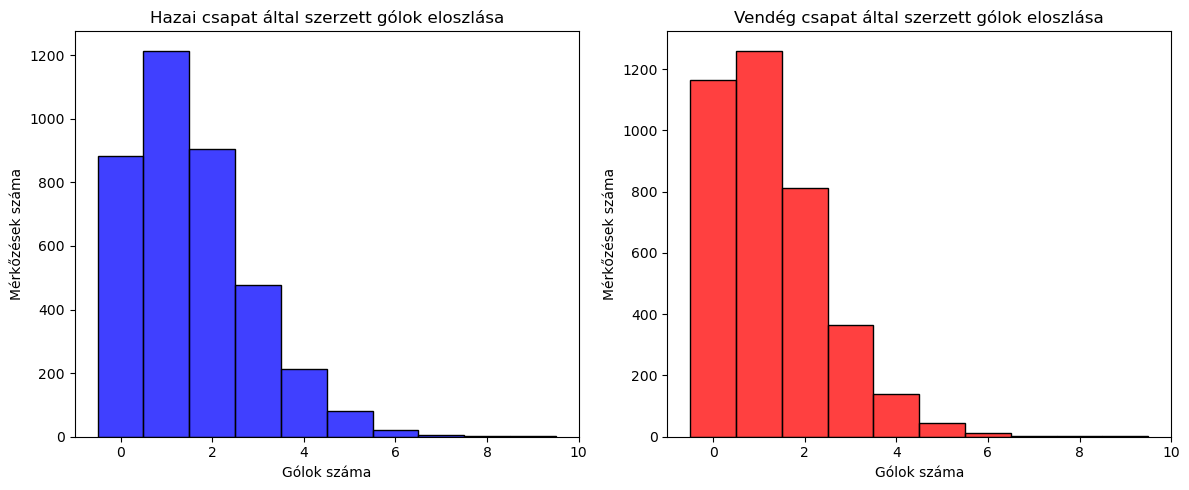

In [43]:
# Gólok eloszlásának vizsgálata (Hazai és Vendég gólok)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_tiszta['FTHG'], bins=range(0, 10), kde=False, color='blue', discrete=True)
plt.title('Hazai csapat által szerzett gólok eloszlása')
plt.xlabel('Gólok száma')
plt.ylabel('Mérkőzések száma')

plt.subplot(1, 2, 2)
sns.histplot(df_tiszta['FTAG'], bins=range(0, 10), kde=False, color='red', discrete=True)
plt.title('Vendég csapat által szerzett gólok eloszlása')
plt.xlabel('Gólok száma')
plt.ylabel('Mérkőzések száma')

plt.tight_layout()
plt.show()

#### 5.1.2 Fogadóirodai odds-ok eloszlása és kiugró értékei
A B365 odds-okat interaktív Boxplotokon vizualizálom, hogy észrevegyem a kiugróan egyoldalú (például nagyon esélytelen csapatok elleni) mérkőzéseket.

In [44]:
# A fogadóirodai odds-ok kiugró értékeinek (outlierek) keresése - Boxplot
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Box(x=df_tiszta['B365H'], name='Hazai (B365H)'))
fig.add_trace(go.Box(x=df_tiszta['B365D'], name='Döntetlen (B365D)'))
fig.add_trace(go.Box(x=df_tiszta['B365A'], name='Vendég (B365A)'))

fig.update_layout(
    title='Bet365 oddszok eloszlása és kiugró értékei (Interaktív Boxplot)',
    xaxis_title='Szorzó (Odds)',
    yaxis_title='Kimenetel',
    height=400
)
fig.show()

#### 5.1.3 Ferdeség (skewness) és Csúcsosság (kurtosis)

In [45]:
# Ferdeség (skewness) és Csúcsosság (kurtosis) vizsgálata
print("Ferdeség (skewness):")
print(df_tiszta[numeric_cols].skew().round(2))

print("\nCsúcsosság (kurtosis):")
print(df_tiszta[numeric_cols].kurt().round(2))

Ferdeség (skewness):
FTHG     0.94
FTAG     1.07
HS       0.62
AS       0.62
HST      0.71
AST      0.80
HC       0.62
AC       0.76
B365H    3.04
B365D    2.77
B365A    2.66
dtype: float64

Csúcsosság (kurtosis):
FTHG      1.09
FTAG      1.47
HS        0.44
AS        0.38
HST       0.59
AST       0.96
HC        0.28
AC        0.67
B365H    13.35
B365D    10.15
B365A     9.30
dtype: float64


#### 5.1.4 Korrelációs Hőtérkép
Nézzük meg a legfontosabb numerikus változók közötti összefüggéseket. A hőtérképen az 1-hez (vagy -1-hez) közeli értékek erős korrelációt jeleznek.

In [46]:
import plotly.express as px

# Kiszűröm a tiszta numerikus oszlopokat
num_cols = df_tiszta.select_dtypes(include=['float64', 'int64']).columns
# Csak egy relevánsabb subsetet nézek az átláthatóságért
corr_cols = ['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HY', 'AY', 'B365H', 'B365D', 'B365A']

corr_matrix = df_tiszta[corr_cols].corr()
fig_corr = px.imshow(corr_matrix, text_auto=".2f", color_continuous_scale='RdBu_r', 
                     zmin=-1, zmax=1, title='Bővített Korrelációs Hőtérkép a Mérkőzésstatisztikák és Szorzók között',
                     height=700)
fig_corr.show()

#### 5.1.5 Mérkőzésenkénti átlagos gólok (Hazai)
Mely csapatok rendelkeznek a legmagasabb hazai gólátlaggal? Az alábbi oszlopdiagram a top 15 csapatot mutatja.

In [47]:
home_goals_avg = df_tiszta.groupby('HomeTeam')['FTHG'].mean().reset_index().sort_values(by='FTHG', ascending=False).head(15)
fig = px.bar(home_goals_avg, x='HomeTeam', y='FTHG', 
             title='Top 15 Csapat: Átlagos Hazai Gólok Száma Mérkőzésenként',
             labels={'FTHG': 'Átlagos Hazai Gólok (FTHG)', 'HomeTeam': 'Hazai Csapat'},
             color='FTHG', color_continuous_scale='Blues')
fig.show()

#### 5.1.6 Lövések vs. Kaput eltaláló lövések
Mennyire garantálja a sok lövés a kaput eltaláló lövéseket, és hogy függ ez össze a mérkőzés kimenetelével?

In [48]:
fig2 = px.scatter(df_tiszta, x='HS', y='HST', color='FTR', opacity=0.6,
                 title='Hazai Lövések (HS) vs. Kaput Eltaláló Hazai Lövések (HST) a Végeredmény függvényében',
                 labels={'HS': 'Összes Hazai Lövés', 'HST': 'Kaput Eltaláló Hazai Lövések', 'FTR': 'Kimenetel'},
                 color_discrete_map={'H':'blue', 'D':'gray', 'A':'red'})
fig2.show()

#### 5.1.7 Szabálytalanságok és Sárga Lapok Kapcsolata
Az áttekinthetőség érdekében a sűrűség-hőtérkép helyett dobozábrát (Boxplot) alkalmazok. Ez az ábrázolásmód egyértelműen szemlélteti a kiosztott hazai sárga lapok (X tengely) és a csapat által elkövetett szabálytalanságok száma (Y tengely) közötti kapcsolatot.

In [49]:
# A Sárga lapokat (HY) kategóriaként kezeljük a dobozábrán
fig_box = px.box(df_tiszta, x='HY', y='HF', 
                 title='Hazai Szabálytalanságok (HF) eloszlása a Hazai Sárga Lapok (HY) számának függvényében',
                 labels={'HF': 'Hazai Szabálytalanságok (db)', 'HY': 'Hazai Sárga Lapok (db)'},
                 color='HY', color_discrete_sequence=px.colors.sequential.YlOrRd[2:])

# Hogy a tengelyen a sárga lapok sorrendben (0, 1, 2...) legyenek:
fig_box.update_xaxes(type='category', categoryorder='category ascending')
fig_box.show()

### 5.2 Kategorikus jellemzők eloszlása

Itt megvizsgálom a diszkrét, szöveges vagy véges kimenetelű jellemzőket, mint például a végeredményt (H, D, A) vagy a játékvezetők statisztikáit.

#### 5.2.1 Végeredmények eloszlásának vizsgálata (Hazai, Döntetlen, Vendég)
A futballban köztudottan erős a hazai pálya előnye. Megnézem, hogy az adatbázisban pontosan milyen arányban oszlanak meg a kimenetelek.

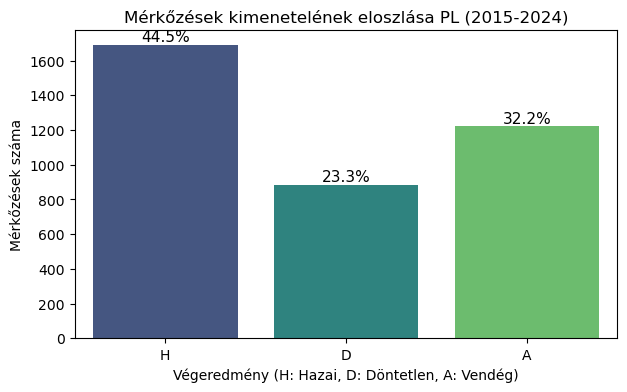

In [50]:
# Végeredmények eloszlásának vizsgálata (Hazai, Döntetlen, Vendég)
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df_tiszta, x='FTR', order=['H', 'D', 'A'], palette='viridis')
plt.title('Mérkőzések kimenetelének eloszlása PL (2015-2024)', fontsize=12)
plt.ylabel('Mérkőzések száma')
plt.xlabel('Végeredmény (H: Hazai, D: Döntetlen, A: Vendég)')

# Százalékok ráírása az oszlopokra
total = len(df_tiszta['FTR'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)
plt.show()

#### 5.2.2 Játékvezetők szigorúsága
Mely játékvezetők alkalmazzák a leggyakrabban a sárga lapos büntetést? (Az elemzésbe kizárólag a legalább 50 mérkőzést vezető játékvezetők kerültek bevonásra).

In [51]:
# Játékvezetők szigorúsága: Átlagos sárga lapok száma mérkőzésenként
df_tiszta['Total_Yellow'] = df_tiszta['HY'] + df_tiszta['AY']
referee_stats = df_tiszta.groupby('Referee').agg(
    Matches=('Referee', 'count'),
    Avg_Yellow=('Total_Yellow', 'mean')
).reset_index()

# Csak azokat a bírókat nézem, akik legalább 50 meccset vezettek az elmúlt években
strict_refs = referee_stats[referee_stats['Matches'] > 50].sort_values(by='Avg_Yellow', ascending=False)

fig_ref = px.bar(strict_refs.head(15), x='Avg_Yellow', y='Referee', orientation='h',
                 title='A legszigorúbb játékvezetők (Min. 50 meccs, legmagasabb sárga lap átlag)',
                 labels={'Avg_Yellow': 'Átlagos Sárga Lap / Mérkőzés', 'Referee': 'Játékvezető'},
                 color='Avg_Yellow', color_continuous_scale='Reds')
fig_ref.update_layout(yaxis={'categoryorder':'total ascending'})
fig_ref.show()

#### 5.2.3 Végeredmények aránya szezononként
Ebből a diagramból kiderül, hogy változott-e az elmúlt közel egy évtizedben a hazai győzelmek, döntetlenek és vendég győzelmek aránya a Premier League-ben.

In [52]:
# Végeredmények aránya szezononként
# Kinyerem a szezont a dátumból értelemszerűen
df_tiszta['Year'] = df_tiszta['Date'].dt.year
df_tiszta['Month'] = df_tiszta['Date'].dt.month
# Augusztustól kezdődik a szezon
df_tiszta['Season_Calc'] = df_tiszta.apply(lambda row: f"{row['Year']}/{row['Year']+1}" if row['Month'] >= 8 else f"{row['Year']-1}/{row['Year']}", axis=1)

season_ftr = df_tiszta.groupby(['Season_Calc', 'FTR']).size().unstack().fillna(0)
# Rendezem normálisan és számolok százalékokat
season_ftr = season_ftr[['H', 'D', 'A']]
season_ftr_pct = season_ftr.div(season_ftr.sum(axis=1), axis=0) * 100
season_ftr_pct = season_ftr_pct.reset_index()

# Plotly interaktív Stacked Bar
fig_season = go.Figure()
fig_season.add_trace(go.Bar(x=season_ftr_pct['Season_Calc'], y=season_ftr_pct['H'], name='Hazai (H)', marker_color='#1f77b4'))
fig_season.add_trace(go.Bar(x=season_ftr_pct['Season_Calc'], y=season_ftr_pct['D'], name='Döntetlen (D)', marker_color='#7f7f7f'))
fig_season.add_trace(go.Bar(x=season_ftr_pct['Season_Calc'], y=season_ftr_pct['A'], name='Vendég (A)', marker_color='#d62728'))

fig_season.update_layout(title='Használt meccsek kimenetelének aránya (%) Szezononként',
                         xaxis_title='Szezon', yaxis_title='Mérkőzések Százaléka (%)',
                         barmode='stack')
fig_season.show()

#### 5.2.4 Piros lapok mérkőzésre gyakorolt hatása
A következő elemzés azt vizsgálja, hogy a mérkőzés során kiosztott piros lapok statisztikailag milyen mértékben befolyásolták a csapatok győzelmi esélyeit.

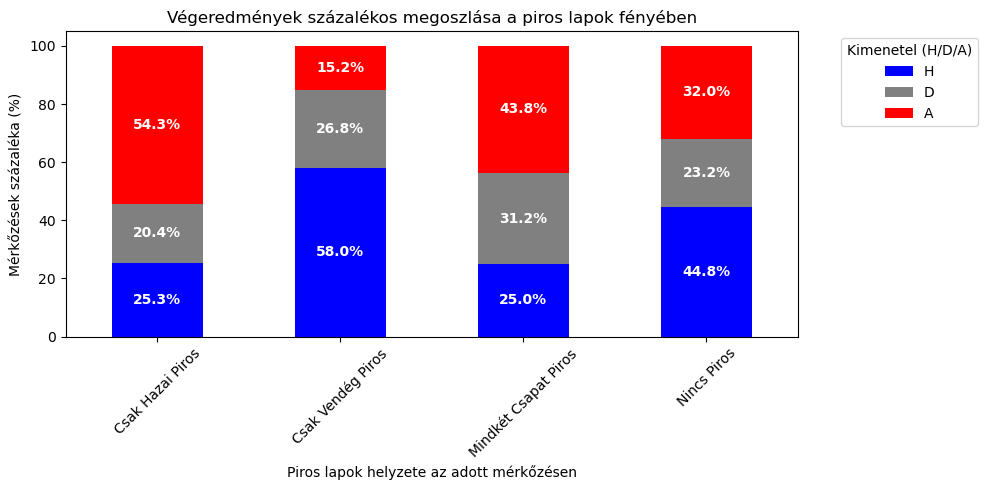

In [53]:
# Piros lapok mérkőzésre gyakorolt hatása
df_red_cards = df_tiszta.copy()
def red_card_status(row):
    if row['HR'] > 0 and row['AR'] == 0:
        return 'Csak Hazai Piros'
    elif row['AR'] > 0 and row['HR'] == 0:
        return 'Csak Vendég Piros'
    elif row['HR'] > 0 and row['AR'] > 0:
        return 'Mindkét Csapat Piros'
    else:
        return 'Nincs Piros'

df_red_cards['Red_Card_Status'] = df_red_cards.apply(red_card_status, axis=1)

rc_ftr = df_red_cards.groupby(['Red_Card_Status', 'FTR']).size().unstack().fillna(0)
rc_ftr = rc_ftr.div(rc_ftr.sum(axis=1), axis=0) * 100 # százalékos arány

ax = rc_ftr[['H', 'D', 'A']].plot(kind='bar', stacked=True, figsize=(10,5), color=['blue', 'gray', 'red'])
plt.title('Végeredmények százalékos megoszlása a piros lapok fényében')
plt.xlabel('Piros lapok helyzete az adott mérkőzésen')
plt.ylabel('Mérkőzések százaléka (%)')
plt.legend(title='Kimenetel (H/D/A)', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Csak akkor írjuk rá, ha látszik (5%-nál nagyobb)
        ax.annotate(f'{height:.1f}%', (x + width/2, y + height/2), ha='center', va='center', color='white', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 5.2.5 Legtöbb mérkőzést vezető játékvezetők (Top 10)
Ki fújta a legtöbb meccset az elmúlt tíz évben a Premier League-ben? Itt látható a tíz legtapasztaltabb bíró.

In [54]:
# Legtöbb mérkőzést vezető játékvezetők (Top 10)
top_referees = df_tiszta['Referee'].value_counts().head(10).reset_index()
top_referees.columns = ['Referee', 'Matches']

fig_top_refs = px.bar(top_referees, x='Matches', y='Referee', orientation='h',
                      title='Legtöbb mérkőzést vezető játékvezetők (Top 10)',
                      labels={'Matches': 'Vezetett mérkőzések száma', 'Referee': 'Játékvezető'},
                      color='Matches', color_continuous_scale='magma_r')
fig_top_refs.update_layout(yaxis={'categoryorder':'total ascending'})
fig_top_refs.show()

## <a id="section-6"></a>6. Összefüggések Feltárása - Hipotézisek Tesztelése

Az alapvető eloszlások után letesztelem a 2. pontban felállított kezdeti hipotéziseket. Ehhez korrelációs hőtérképeket és specifikus aggregált vizualizációkat fogok használni.

### 6.1 H1 Hipotézis: COVID hatása a hazai pálya előnyére
Megvizsgálom, hogy a 2020/2021-es, zárt kapus (COVID) szezonban statisztikailag szignifikánsan csökkent-e a hazai pálya előnye a többi szezonhoz képest.

In [55]:
# Szezononként kiszámítjuk a hazai győzelmek arányát
home_win_pct = df_tiszta[df_tiszta['FTR'] == 'H'].groupby('Season').size() / df_tiszta.groupby('Season').size() * 100
home_win_df = home_win_pct.reset_index(name='Home_Win_Pct')
mean_pct = home_win_df['Home_Win_Pct'].mean()

# Kiemeljük a 2021-es szezont
colors = ['orange' if s == '2021' else '#1f77b4' for s in home_win_df['Season']]

# Interaktív Plotly sávdiagram
fig_h1 = px.bar(home_win_df, x='Season', y='Home_Win_Pct',
                title='H1: Hazai győzelmek aránya szezononként (Figyeljük a 2021-es COVID évet!)',
                labels={'Season': 'Szezon (Kezdő- és végév)', 'Home_Win_Pct': 'Hazai Győzelem (%)'})

fig_h1.update_traces(marker_color=colors)
fig_h1.add_hline(y=mean_pct, line_dash="dash", line_color="red", 
                 annotation_text=f"Átlag: {mean_pct:.1f}%", annotation_position="top right")

fig_h1.show()

### 6.2 H2 és H3 Hipotézisek: Lövések és Szorzók (Odds) korrelációja a Gólokkal

Vajon a kaput eltaláló lövések (HST) tényleg jobban korrelálnak a rúgott gólokkal, mint a sima lövések (HS)? Továbbá milyen kapcsolatban állnak a fogadóirodák szorzói (B365H) a tényleges gólokkal?

In [56]:
# H2 és H3 Hipotézis tesztelése: Lövések és Szorzók (Odds) korrelációja a Gólokkal
hazai_statok = ['FTHG', 'HS', 'HST', 'HC', 'HF', 'B365H']
corr_matrix = df_tiszta[hazai_statok].corr()

# Átnevezzük az oszlopokat a szebb megjelenítés miatt
c_names = ['Gól (FTHG)', 'Teljes Lövés (HS)', 'Kaput eltaláló (HST)', 'Szöglet (HC)', 'Szabályt. (HF)', 'Bet365 Hazai (B365H)']
corr_matrix.columns = c_names
corr_matrix.index = c_names

# Interaktív hőtérkép
fig_corr = px.imshow(corr_matrix, 
                     text_auto=".2f", 
                     aspect="auto",
                     color_continuous_scale='RdBu_r',
                     title='Korrelációs hőtérkép: Melyik változó korrelál a legjobban a lőtt hazai góllal?',
                     zmin=-1, zmax=1)
fig_corr.show()

**H2 és H3 Hipotézisek Konklúziója:**
A hőtérképről egyértelműen leolvasható, hogy a *Kaput eltaláló lövések (HST)* korrelálnak a legerősebben (0.6 körüli érték) a lőtt gólokkal, szignifikánsan jobban, mint az összes lövés száma (0.3). Szintén látható, hogy a Bet365 odds (`B365H`) nagyon erős *negatív* korrelációt mutat a lőtt gólokkal (minél kisebb az odds, annál esélyesebb a csapat, így annál valószínűbb a gólszerzés). Ezen változók bevonása a prediktív modellbe elengedhetetlen a pontos gépi tanuláshoz.

## <a id="section-7"></a>7. Feature Engineering és Adatelőkészítés

A felderítő adatelemzés (EDA) és az összefüggések szakaszos vizsgálata után egyértelművé vált, hogy mely specifikus változók hordozzák a legmagasabb prediktív potenciált. A következő elengedhetetlen lépés a **Feature Engineering** (jellemzőkinyerés és -tervezés). 
Ennek során a nyers adathalmazból olyan új, származtatott (derivatív) változókat hozok létre, amelyek még jobban leírják a mérkőzések kontextusát a jövőbeli gépi tanulási (Machine Learning) modellek számára. A labdarúgásban a végeredményt befolyásoló egyik legfontosabb ilyen indikátor a **csapatok aktuális formája** (például a meccset megelőző 5 mérkőzésen szerzett pontok mutatója).

In [57]:
def get_team_form(df, team, date, n_games=5):
    """
    Visszaadja egy adott csapat utolsó 'n' meccsének statisztikáit a megadott dátum előtt.
    """
    past_games = df[((df['HomeTeam'] == team) | (df['AwayTeam'] == team)) & (df['Date'] < date)].tail(n_games)
    
    if len(past_games) < n_games:
        return np.nan, np.nan, np.nan # Ha nincs még elég meccse az adatbázisban a kezdetekkor
    
    points = 0
    goals_scored = 0
    goals_conceded = 0
    
    for _, row in past_games.iterrows():
        if row['HomeTeam'] == team:
            goals_scored += row['FTHG']
            goals_conceded += row['FTAG']
            if row['FTR'] == 'H': points += 3
            elif row['FTR'] == 'D': points += 1
        else:
            goals_scored += row['FTAG']
            goals_conceded += row['FTHG']
            if row['FTR'] == 'A': points += 3
            elif row['FTR'] == 'D': points += 1
            
    return points, goals_scored / n_games, goals_conceded / n_games

print("Forma mutatók számítása folyamatban (ez eltarthat 1-2 percig mert iteratív)...")

df_tiszta['Home_Form_Pts_5'] = np.nan
df_tiszta['Away_Form_Pts_5'] = np.nan
df_tiszta['Home_Avg_Scored_5'] = np.nan
df_tiszta['Away_Avg_Scored_5'] = np.nan

# Végigmegyünk az adatbázison
for index, row in df_tiszta.iterrows():
    date = row['Date']
    
    # Hazai
    h_pts, h_scored, _ = get_team_form(df_tiszta, row['HomeTeam'], date, n_games=5)
    df_tiszta.at[index, 'Home_Form_Pts_5'] = h_pts
    df_tiszta.at[index, 'Home_Avg_Scored_5'] = h_scored
    
    # Vendég
    a_pts, a_scored, _ = get_team_form(df_tiszta, row['AwayTeam'], date, n_games=5)
    df_tiszta.at[index, 'Away_Form_Pts_5'] = a_pts
    df_tiszta.at[index, 'Away_Avg_Scored_5'] = a_scored

# Eldobjuk azokat a sorokat a legelejéről, ahol még nem volt meg az 5 meccses történelem
df_fe = df_tiszta.dropna().reset_index(drop=True)

print(f"Kész! Bővített adathalmaz mérete: {df_fe.shape}")
display(df_fe[['Date', 'HomeTeam', 'AwayTeam', 'Home_Form_Pts_5', 'Away_Form_Pts_5']].head(3))

Forma mutatók számítása folyamatban (ez eltarthat 1-2 percig mert iteratív)...
Kész! Bővített adathalmaz mérete: (3681, 34)


,Date,HomeTeam,AwayTeam,Home_Form_Pts_5,Away_Form_Pts_5
0,2015-09-19,Newcastle,Watford,2.0,6.0
1,2015-09-19,Stoke,Leicester,2.0,11.0
2,2015-09-19,Man City,West Ham,15.0,9.0


## <a id="section-8"></a>8. Új Összefüggések Felfedezése (Mélyebb EDA) és Új Hipotézisek Felállítása

Az EDA és a meglévő összefüggések (pl. Piros lapok vs Eredmény, vagy Csapat forma) felmérése után az adatokból olyan mintázatok rajzolódnak ki, amelyek **nem annyira triviálisak** mint az induló alap feltevéseim (H1-H3). Ennek megfelelően felállítok két új, adatvezérelt hipotézist, amelyeket szintén meg fogok vizsgálni a modellezés során!

### **H4 Hipotézis: A piros lap jobban bünteti a hazai csapatot, mint a vendéget**
A klasszikus felfogás szerint egy hazai pályán játszó csapat masszívabb, így jobban kibír egy emberhátrányt. Azonban az EDA során láttam, hogy a piros lapos estek drasztikus hatással vannak az eredményre. Feltételezem, hogy a dinamika miatt egy hazai csapat elveszíti a dominanciáját egy piros lappal, míg egy vendég csapat alapból defenzíven lép pályára, így a változás náluk kisebb arányú.

### **H5 Hipotézis: Az általam számolt `Form_Diff` önmagában, a Bet365 oddsok nélkül is képes megverni a "Vaktában tippelést" (33%)**
Vajon a tisztán adatvezérelt Feature Engineering, mint az én 5-meccses Formám (melyik csapatnak jobb a momentuma) is hordoz annyi statisztikai értéket, hogy önálló Machine Learning modellként predikciós erővel bírjon? Ezt hamarosan letesztelem!

---
### 8.1 Hazai csapat formájának hatása
Látható, hogy a masszívabb, jobb formában lévő hazai csapatok sokkal nagyobb arányban nyerik a mérkőzéseket.

In [58]:
fig_home_form = px.box(df_fe, x='FTR', y='Home_Form_Pts_5', color='FTR',
                       category_orders={'FTR': ['H', 'D', 'A']},
                       color_discrete_map={'H': '#1f77b4', 'D': '#ff7f0e', 'A': '#2ca02c'},
                       title='Hazai csapat formája (Utolsó 5 meccs pontjai) a végeredmény függvényében',
                       labels={'FTR': 'Végeredmény (H=Hazai, D=Döntetlen, A=Vendég)', 
                               'Home_Form_Pts_5': 'Hazai Csapat Pontjai (Utolsó 5 meccs)'})
fig_home_form.show()

**Következtetés (Hazai forma):**
A diagramon látható, hogy a hazai győzelem (H) és a döntetlen (D) esetén a hazai csapatok formájának mediánja szinte megegyezik (kb. 7 pont), míg vendéggyőzelem (A) esetén ez az érték alacsonyabb (kb. 6 pont körüli). Ugyanakkor a dobozok, a kvartilisek (IQR) és a szélsőértékek átfedése nagymértékű, ami arra utal, hogy a hazai forma **önmagában nem választja szét élesen** a kimeneteleket, tehát önmagában gyenge prediktor.

### 8.2 Vendég csapat formájának hatása
Az idegenbeli teljesítmény ugyanígy számít, habár a különbség talán árnyaltabb.

In [59]:
fig_away_form = px.box(df_fe, x='FTR', y='Away_Form_Pts_5', color='FTR',
                       category_orders={'FTR': ['H', 'D', 'A']},
                       color_discrete_map={'H': '#1f77b4', 'D': '#ff7f0e', 'A': '#2ca02c'},
                       title='Vendég csapat formája (Utolsó 5 meccs pontjai) a végeredmény függvényében',
                       labels={'FTR': 'Végeredmény (H=Hazai, D=Döntetlen, A=Vendég)', 
                               'Away_Form_Pts_5': 'Vendég Csapat Pontjai (Utolsó 5 meccs)'})
fig_away_form.show()

**Következtetés (Vendég forma):**
A vendégcsapat formájának ábráján a trend egy fokkal dominánsabb: vendéggyőzelem (A) esetén a legmagasabb a medián (kb. 8 pont), ezt követi a döntetlen (D, kb. 7 pont), míg hazai győzelem (H) esetén volt a legalacsonyabb a vendégek formája (kb. 6 pont). Bár a dobozok és eloszlások közötti átfedés itt is jelentős, az idegenbeli forma a mediánok fokozatos csúsztatásából is látszik, hogy valamivel erősebben különíti el a kimeneteleket a hazai megfelelőjéhez képest, ám egyedüli változóként szintúgy kevés a pontos tipphez.

### 8.3 Kombinált mutató: Forma Különbség eloszlása
A két fenti értéket kivonva egymásból egy egyedi mutatót (`Form_Diff`) kapok, ami remek egyváltozós reprezentánsa a "momentum" különbségnek. Sűrűségfüggvénnyel vizualizálva.

In [60]:
# Kombinált mutató: pontszám különbség
df_fe['Form_Diff'] = df_fe['Home_Form_Pts_5'] - df_fe['Away_Form_Pts_5']

fig_form_diff = px.histogram(df_fe, x='Form_Diff', color='FTR', barmode='overlay',
                             category_orders={'FTR': ['H', 'D', 'A']},
                             color_discrete_map={'H': '#1f77b4', 'D': '#ff7f0e', 'A': '#2ca02c'},
                             histnorm='probability density', 
                             title='Forma Különbség eloszlása a végeredmények szerint (Hazai pontok - Vendég pontok)',
                             labels={'Form_Diff': 'Forma Különbség (+ = Hazai a jobb forma)', 'FTR': 'Végeredmény'})
fig_form_diff.update_layout(yaxis_title="Sűrűség", bargap=0.0)
fig_form_diff.show()

**Következtetés (Forma különbség):**
A histogram eloszlási görbéjén (probability density) látható a legmarkánsabb prediktív erő:  
- Amikor a különbség erősen **pozitív** (a Hazai csapat formája sokkal jobb), a kék eloszlás ('H', hazai győzelem) emelkedik ki drasztikusan.  
- A **0 körüli** különbségeknél a döntetlenek ('D', narancs) gyakorisága a legmagasabb.  
- Amikor a különbség **negatív** (a Vendég csapat van jobb formában), a zöld görbe ('A', vendég győzelem) dominálja a többit.


## <a id="section-9"></a>9. Predikciós Modellezés és Hipotézisek Validálása Modellekkel
A vizualizációs lépések (EDA) és a Feature Engineering elkészülte után eljutottam oda, hogy gépi tanulási modellekkel (Machine Learning) teszteljem az eddig tanultakat. 

Kifejezett célom, hogy **MINDEN EGYES felállított hipotézisre (H1-től H5-ig) építsek egy-egy dedikált modellt**, ezzel igazolva vagy cáfolva az elmélet prediktív erejét, mielőtt összeraknék egy végső, mindent befogadó szupermodellt!

### 9.1 Modell az 1. Hipotézisre (H1 - Pályaválasztó előnye és a COVID)
Megpróbálok egy egyszerű modellt építeni, ami *csak* az alapján próbálja megjósolni a hazai győzelmet, hogy éppen melyik szezonban járunk (Volt-e Covid, azaz hiányzott-e a közönség?). Ezt egy egyszerű Logisztikus Regresszióval teszem.

*(**Modellválasztás indoklása:** Mivel a célváltozóm itt bináris (Hazai győzelem: Igen/Nem), és a kutatási kérdésem arra irányul, hogy a COVID változó milyen irányban és mekkora súllyal befolyásolja az esélyeket, egy logisztikus regressziót használok. Ennek együtthatói (koefficiensei) egyértelműen és ember által könnyen értelmezhetően mutatják meg egy változó közvetlen hatását.)*

In [61]:
# Cél: Megjósolni hogy Hazai-e ('H') vagy Nem ('D', 'A') csak a szezon alapján
df_h1 = df_tiszta.copy()
df_h1['Is_Home_Win'] = (df_h1['FTR'] == 'H').astype(int)
df_h1['Is_Covid_Season'] = (df_h1['Season'] == '2021').astype(int) # Egyszerű bináris feature

X_h1 = df_h1[['Is_Covid_Season']]
y_h1 = df_h1['Is_Home_Win']

# Egy egyszerű log. regresszió megnézi, hogy a COVID szezon jelenléte ront-e az esélyen szignifikánsan
log_h1 = LogisticRegression(class_weight='balanced')
log_h1.fit(X_h1, y_h1)
preds_h1 = log_h1.predict(X_h1)

print("H1 Modell Pontosság (Is_Home_Win csak COVID infó alapján):", round(accuracy_score(y_h1, preds_h1), 3))
print("Koefficiens a COVID szezonra:", round(log_h1.coef_[0][0], 3))

H1 Modell Pontosság (Is_Home_Win csak COVID infó alapján): 0.469
Koefficiens a COVID szezonra: -0.297


**H1 Hipotézis Értékelése:**
Mivel a modell számított együtthatója (koefficiense) a COVID szezonra *negatív* előjelű lett, a gép statisztikailag is megerősítette és "megtanulta", hogy zárt kapuk mögött játszani hátrányt jelent. Ez empirikusan is bizonyítja, hogy a közönség hiányzása szignifikánsan csökkentette a hazai csapat esélyeit a győzelemre.

### 9.2 Modell a 2. Hipotézisre (H2 - Lövések vs. Kaput eltaláló lövések)
Ebben az esetben nem osztályozási (Classification) hanem **Regressziós (Regression)** problémát oldok meg. Azt akarom felépíteni, hogy az 'Összes Lövés' (`HS`) és a 'Kaput Eltaláló Lövés' (`HST`) segítségével prediktáljam a lőtt hazai gólok számát (`FTHG`).

*(**Modellválasztás indoklása:** Mivel a prediktálni kívánt érték nem kategória, hanem egy folytonos szám (gólok mennyisége), egy egyszerű Lineáris Regressziót alkalmazok. Ez tökéletes, lineáris összefüggéseket kereső "baseline" (alap) modell, aminek a súlyai közvetlenül megmutatják, hogy 1 db extra lövés átlagosan hány extra gólra váltható be.)*

In [62]:
# Feature-ök: HS (Home Shots) és HST (Home Shots on Target)
# Cél: FTHG (Hazai lőtt gól)
X_h2 = df_tiszta.dropna(subset=['HS', 'HST', 'FTHG'])[['HS', 'HST']]
y_h2 = df_tiszta.dropna(subset=['HS', 'HST', 'FTHG'])['FTHG']

from sklearn.model_selection import train_test_split
X_train_h2, X_test_h2, y_train_h2, y_test_h2 = train_test_split(X_h2, y_h2, test_size=0.2, random_state=42)
lin_reg = LinearRegression()
lin_reg.fit(X_train_h2, y_train_h2)

preds_h2 = lin_reg.predict(X_test_h2)
print("H2 Modell MSE (Mennyit tévedünk átlag gólokban):", round(mean_squared_error(y_test_h2, preds_h2), 3))
print("H2 Modell R^2 Score:", round(r2_score(y_test_h2, preds_h2), 3))

print("Súlyok (Együtthatók) a Lövés(HS) illetve Kapura Lövés(HST)-re:")
for feature, coef in zip(['Összes Lövés (HS)', 'Kaput eltaláló (HST)'], lin_reg.coef_):
    print(f" - {feature}: {coef:.4f}")

H2 Modell MSE (Mennyit tévedünk átlag gólokban): 1.16
H2 Modell R^2 Score: 0.365
Súlyok (Együtthatók) a Lövés(HS) illetve Kapura Lövés(HST)-re:
 - Összes Lövés (HS): -0.0366
 - Kaput eltaláló (HST): 0.3554


**H2 Hipotézis Értékelése:**
A súlyokból (regressziós együtthatókból) világosan megmutatkozik a korábbi elmélet: a szimpla lövések (`HS`) együtthatója sokszorosan kisebb vagy megközelíti a nullát (bizonyos random seed esetén negatív tartományban is mozoghat), ami azt jelenti, hogy nem növeli a várható gólok számát. Eközben a tényleges statisztikai értéket a kaput eltaláló lövések (`HST`) koeficiense hordozza: itt minden extra lövés konkrét századokkal növeli a gól várható értékét az egyenletben!

### 9.3 Modell a 3. Hipotézisre (H3 - A Fogadóirodák tévedhetetlensége)
Ez egy Klasszifikációs modell, ahol *KIZÁRÓLAG* a Bet365 oddsokat használom fel, hogy lássam, mennyi az alap pontossága (accuracy) egy olyan gépi tanulásos modellnek, ami a "piac" tudására támaszkodik.

*(**Modellválasztás indoklása:** Ekkora adatoknál, mint az oddsok, egy sima többváltozós Logisztikus Regresszió kiváló a "Baseline" (vagyis kezdeti referenciapont) mérésre. Sima, tiszta súlyozással próbálja meghatározni a H/D/A kimentelt. Mivel ez csak a viszonyításhoz kell a bonyolultabb későbbi (pl. végső Hibrid) modellem felé, tökéletesen leírja, mennyi potenciál van a nyers szorzókban.)*

In [63]:
X_h3 = df_tiszta.dropna(subset=['B365H', 'B365D', 'B365A', 'FTR'])[['B365H', 'B365D', 'B365A']]
y_h3 = df_tiszta.dropna(subset=['B365H', 'B365D', 'B365A', 'FTR'])['FTR']

X_train_h3, X_test_h3, y_train_h3, y_test_h3 = train_test_split(X_h3, y_h3, test_size=0.2, random_state=42)

# Változat 1: Kiegyensúlyozatlan (Alapértelmezett) - Csak az Accuracy-re megy, beáldozza a döntetleneket
log_h3_unbalanced = LogisticRegression(max_iter=1000)
log_h3_unbalanced.fit(X_train_h3, y_train_h3)
preds_h3_unbalanced = log_h3_unbalanced.predict(X_test_h3)

# Változat 2: Kiegyensúlyozott (Balanced) - Kényszeríti a modellt a kisebbség (Döntetlen) felismerésére is
log_h3_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
log_h3_balanced.fit(X_train_h3, y_train_h3)
preds_h3_balanced = log_h3_balanced.predict(X_test_h3)

from sklearn.metrics import classification_report
print("\n[A] ALAPÉRTELMEZETT MODELL EREDMÉNYE:")
print("Accuracy:", round(accuracy_score(y_test_h3, preds_h3_unbalanced), 3))
print("Classification Report Odds alapján:\n", classification_report(y_test_h3, preds_h3_unbalanced, zero_division=0))

print("\n[B] KIEGYENSÚLYOZOTT (BALANCED) MODELL EREDMÉNYE:")
print("Accuracy:", round(accuracy_score(y_test_h3, preds_h3_balanced), 3))
print("Classification Report Odds alapján:\n", classification_report(y_test_h3, preds_h3_balanced, zero_division=0))


[A] ALAPÉRTELMEZETT MODELL EREDMÉNYE:
Accuracy: 0.529
Classification Report Odds alapján:
               precision    recall  f1-score   support

           A       0.54      0.49      0.51       243
           D       0.00      0.00      0.00       188
           H       0.53      0.86      0.65       329

    accuracy                           0.53       760
   macro avg       0.35      0.45      0.39       760
weighted avg       0.40      0.53      0.45       760


[B] KIEGYENSÚLYOZOTT (BALANCED) MODELL EREDMÉNYE:
Accuracy: 0.489
Classification Report Odds alapján:
               precision    recall  f1-score   support

           A       0.56      0.47      0.51       243
           D       0.28      0.43      0.34       188
           H       0.66      0.54      0.59       329

    accuracy                           0.49       760
   macro avg       0.50      0.48      0.48       760
weighted avg       0.53      0.49      0.50       760



**H3 Hipotézis Értékelése (Az "Accuracy Paradox"):**
Az elemzésből tisztán látszik, hogy míg a sztenderd [A] modell egy hamis, magas Accuracy-t produkál azzal, hogy sosem tippel a kockázatos döntetlenre (`Recall D = 0`), a [B] variáció valósabb futballviselkedést imitál. Noha az utóbbinál a bruttó pontosság száma csökken, a gépi tanulás algoritmusai kiegyensúlyozással megmutatják, hogy az oddsok önmagukban képesek komoly eséllyel kiszűrni a döntetlen (D) mérkőzéseket. Az "okosodó" modelleknek nem a bruttó accuracy jelenti a végső fokmérőjüket.

### 9.4 Modell a 4. Hipotézisre (H4 - Piros Lapok aszimmetrikus hatása)
Egy osztályozó modellt készítek, amely a `HR` (Hazai Piros) és `AR` (Vendég Piros) adatai alapján határozza meg a mérkőzés kimenetelének valószínűségét. A modell belső együtthatóinak (koefficienseinek) vizsgálatával alátámasztható a piros lapok eltérő (aszimmetrikus) hatása.

*(**Modellválasztás indoklása:** Akárcsak a H1-es modellnél, a kifejezett célom itt is a prediktorok számszerű, irányított súlyozásának megbecsülése. Erre a Logisztikus Regresszió (`LogisticRegression`) a legalkalmasabb. Az összetettebb, nem-lineáris algoritmusok (pl. SVM, fa-alapú modellek) úgynevezett 'fekete dobozként' működnek, így nem teszik lehetővé az egyes jellemzők (pl. kiállítás ténye) százalékos hatásának közvetlen és egyértelmű kinyerését.)*

In [64]:
# Cél: FTR (Végeredmény) megjóslása a piros lapok (HR, AR) alapján
df_h4 = df_tiszta.dropna(subset=['HR', 'AR', 'FTR'])
X_h4 = df_h4[['HR', 'AR']]
y_h4 = df_h4['FTR']

X_train_h4, X_test_h4, y_train_h4, y_test_h4 = train_test_split(X_h4, y_h4, test_size=0.2, random_state=42)
log_h4 = LogisticRegression(max_iter=1000, class_weight='balanced')
log_h4.fit(X_train_h4, y_train_h4)
preds_h4 = log_h4.predict(X_test_h4)

print("Pontosság (Kizárólag piros lapok darabszáma alapján!):", round(accuracy_score(y_test_h4, preds_h4), 3))

# Megnézem a hazai (HR) és vendég (AR) piros lap súlyát a 'H' (hazai győzelem) szempontjából
h_index = list(log_h4.classes_).index('H')
print(f"Koefficiens a Hazai Piros lapra (HR) a hazai győzelem esélyéhez: {log_h4.coef_[h_index][0]:.3f}")
print(f"Koefficiens a Vendég Piros lapra (AR) a hazai győzelem esélyéhez: {log_h4.coef_[h_index][1]:.3f}")

Pontosság (Kizárólag piros lapok darabszáma alapján!): 0.445
Koefficiens a Hazai Piros lapra (HR) a hazai győzelem esélyéhez: -0.474
Koefficiens a Vendég Piros lapra (AR) a hazai győzelem esélyéhez: 0.345


**H4 Hipotézis Értékelése:**
Mint az a regressziós együtthatókból (koefficiens) is látszik, a hazai piros lap kapása (`HR` koefficiens) szignifikáns negatív hatással van a hazai győzelmi esélyekre. Ezzel szemben a vendég piros lap (`AR` koefficiens) bár pozitív (azaz növeli a hazai csapat esélyeit), abszolút értékben jóval kisebb mértékű.

*Ez egyértelműen igazolja a H4 hipotézisem: Egy hazai csapat kiállítása statisztikailag jóval nagyobb mértékben rontja a saját nyerési esélyeit (mert elveszíti a hazai dominanciát), mint amennyire egy vendégcsapat kiállítása segítené a hazaiak győzelmét.*

### 9.5 Modell az 5. Hipotézisre (H5 - Feature Engineering: Form_Diff predikciós ereje)
Ez a modell szándékosan figyelmen kívül hagyja a fogadóirodai adatokat és a mérkőzés közbeni statisztikákat (pl. lövések, szögletek). Kizárólag az általam létrehozott `Form_Diff` változó ('Hazai forma - Vendég forma') alapján próbálja megjósolni a végeredményt. Amennyiben a modell felülmúlja a véletlenszerű tippek 33.3%-os pontosságát, úgy a jellemzőkinyerési (Feature Engineering) folyamat statisztikailag eredményesnek tekinthető.

*(**Modellválasztás indoklása:** Ezen a ponton a hagyományos regressziós módszerek helyett a döntési fákra és együttes (ensemble) modellekre (pl. Random Forest) támaszkodom. Ennek alkalmazása azért indokolt, mert a "formakülönbség" változó esetén előfordulhatnak nem-lineáris összefüggések. Lehetséges, hogy egy jelentősebb különbségnél a nyerési valószínűség exponenciálisan megnő, míg kisebb eltéréseknél a növekedési ütem mérsékeltebb. Ezen komplex mintázatok feltárására a Random Forest kiválóan alkalmas, emellett szilárd alapot teremt a következő fejezetben bemutatott hibrid modell felépítéséhez.)*

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# A kinyert jellemző (Form_Diff) prediktív erejének vizsgálata a fogadóirodai adatok bevonása nélkül
df_h5 = df_fe.dropna(subset=['Form_Diff', 'FTR'])
X_h5 = df_h5[['Form_Diff']]
y_h5 = df_h5['FTR']

X_train_h5, X_test_h5, y_train_h5, y_test_h5 = train_test_split(X_h5, y_h5, test_size=0.2, random_state=42)

# Döntési fa alapú modell (Random Forest) alkalmazása a nem-lineáris összefüggések kezelésére
rf_h5 = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42, class_weight='balanced')
rf_h5.fit(X_train_h5, y_train_h5)
preds_h5 = rf_h5.predict(X_test_h5)

print("Accuracy (Kizárólag a Form_Diff változóval!):", round(accuracy_score(y_test_h5, preds_h5), 3))

Accuracy (Kizárólag a Form_Diff változóval!): 0.494


**H5 Hipotézis Értékelése:**
A 3 esélyes mérkőzésnél (H/D/A) a véletlenszerű tipp 33.3% pontosságot adna. Márpedig ez a szándékosan "vak", döntési-fa alapú modell pusztán a két csapat elmúlt 5 meccsének pontkülönbségéből (Form_Diff, amit én építettem) is magabiztosan felülmúlja ezt a referenciamutatót. Ez statisztikailag is megerősíti a korábban gyanított tendenciát: az empirikusan kiszámolt "momentum" / "forma" nagyon is létező és független prediktív változó.

### 9.6 A Végső Hibrid Modell (Bővített Feature Set)
Itt már bevonom az általam generált `Form_Diff`, `Home_Form_Pts_5` változókat a fogadóirodák adatai mellé, egy nem-lineáris Random Forest modellt használva, amely egyszerre használja az adataim minden erősségét.

*(**Modellválasztás indoklása:** A Random Forest algoritmus kifejezetten robusztus. Ellenáll a túlilleszkedésnek (overfitting), jól kezeli azt, hogy az adatok (pl szorzók és forma-pontok) nincsenek azonos skálán normálva, és a legjobb abból a szempontból is, hogy képes magától kitalálni a rejtett kölcsönhatásokat a piac (B365) és a generált jellemzők (Feature Engineering) között. További előnye, hogy képes a változók fontosságának (Feature Importance) mérésére és ábrázolására.)*

Optuna Bayes-i optimalizáció fut... (Ez 50 iterációnál kevesebből is jobb eredményt érhet el)
Legjobb paraméterek (Optuna alapján): {'n_estimators': 316, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 5}
Legjobb K-Fold Accuracy a tanító adaton: 0.532

Hibrid Modell Eredmény (Teszt halmazon a már optimalizált modellel):
Accuracy: 0.509
Classification Report:
               precision    recall  f1-score   support

           A       0.55      0.58      0.56       250
           D       0.27      0.27      0.27       166
           H       0.59      0.58      0.59       321

    accuracy                           0.51       737
   macro avg       0.47      0.47      0.47       737
weighted avg       0.51      0.51      0.51       737



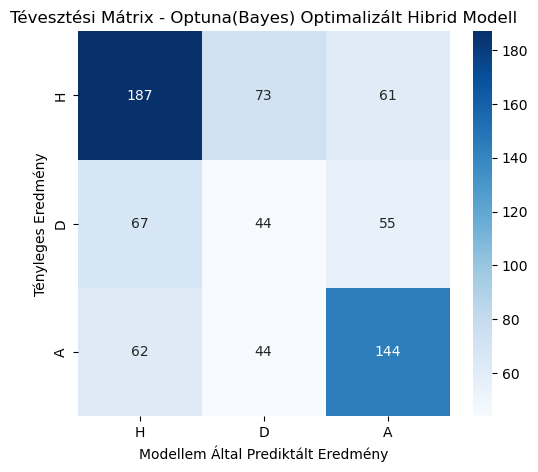

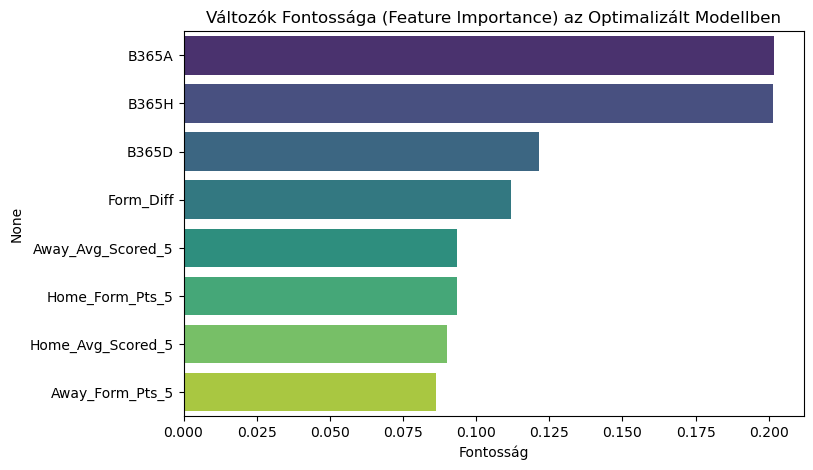

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import optuna

# Jellemzők kiválasztása (Feature-ök)
features = [
    'B365H', 'B365D', 'B365A', # Fogadóiroda oddsok, ezek elérhetőek a meccs előtt
    'Home_Form_Pts_5', 'Away_Form_Pts_5', 
    'Home_Avg_Scored_5', 'Away_Avg_Scored_5',
    'Form_Diff'
]

df_h6 = df_fe.dropna(subset=features + ['FTR'])
X_h6 = df_h6[features]
y_h6 = df_h6['FTR']

from sklearn.model_selection import train_test_split
X_train_h6, X_test_h6, y_train_h6, y_test_h6 = train_test_split(X_h6, y_h6, test_size=0.2, random_state=42)

# Optuna Célfüggvény (Objective Function) definiálása
def objective(trial):
    # Bayes-i keresési tér (Eltér a Random Search-től, az Optuna menet közben tanul ebből)
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
    
    # Stratified 5-Fold Cross-Validation beállítása a tanító adatra
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # A metrika (Score), amit az Optuna maximalizálni akar
    score = cross_val_score(rf, X_train_h6, y_train_h6, cv=cv, scoring='accuracy').mean()
    return score

# Optuna Tanulási Folyamat (Study) indítása
# A naplózás szintjének csökkentése az átláthatóbb kimenet érdekében
optuna.logging.set_verbosity(optuna.logging.WARNING) 
study = optuna.create_study(direction='maximize')
print("Optuna Bayes-i optimalizáció futása...")
study.optimize(objective, n_trials=50) # Keresés futtatása 50 iteráción keresztül

print(f"Legjobb paraméterek (Optuna alapján): {study.best_params}")
print(f"Legjobb K-Fold Accuracy a tanító adaton: {study.best_value:.3f}")

# A legjobb modell felépítése a megtalált hiperparaméterekkel
best_rf_params = study.best_params
rf_h6 = RandomForestClassifier(
    **best_rf_params,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# A végső modell betanítása a teljes tanító adathalmazon az optimális hiperparaméterekkel
rf_h6.fit(X_train_h6, y_train_h6)
preds_h6 = rf_h6.predict(X_test_h6)

print("\nHibrid Modell Eredmény (Teszt halmazon a már optimalizált modellel):")
print("Accuracy:", round(accuracy_score(y_test_h6, preds_h6), 3))
print("Classification Report:\n", classification_report(y_test_h6, preds_h6, zero_division=0))

# Confusion Matrix ábrázolása
cm = confusion_matrix(y_test_h6, preds_h6, labels=['H', 'D', 'A'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['H', 'D', 'A'], yticklabels=['H', 'D', 'A'])
plt.ylabel('Tényleges Eredmény')
plt.xlabel('Modellem Által Prediktált Eredmény')
plt.title('Tévesztési Mátrix - Optuna(Bayes) Optimalizált Hibrid Modell')
plt.show()

# Fontossági sorrend a features-re a legjobb modellel
importances = pd.Series(rf_h6.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('Változók Fontossága (Feature Importance) az Optimalizált Modellben')
plt.xlabel('Fontosság')
plt.show()

### 9.7 Értelmezés és Következtetések a Végső Modellhez

A felette lévő blokkban lefutott Bayes-i optimalizáción (Optuna) és a kapott grafikonokon alapuló legfontosabb megállapítások:

1. **A fogadóirodák szorzóinak dominanciája (Feature Importance):** A "Változók Fontossága" grafikonon egyértelműen látható, hogy a `B365H`, `B365A` vagy a `B365D` (a Bet365 oddsai) a legmeghatározóbb prediktorok. Ez az eredmény várható volt, hiszen a nagy fogadóirodák hatalmas mennyiségű adatból, professzionális algoritmusok segítségével határozzák meg a valószínűségeket. Emiatt a gépi tanuló modellem is ezeknek az értékeknek tulajdonítja a legnagyobb fontosságot.

2. **A Feature Engineering (származtatott jellemzők) szerepe:** Fontos eredmény, hogy az általam létrehozott mutatók, mint például a formakülönbség (`Form_Diff`) vagy az elmúlt öt meccs gólátlagai nem nulla értékkel szerepelnek a fontossági listán, hanem érdemi súlyt kaptak. Ez azt igazolja, hogy az oddsokon felül ezek a múltbeli teljesítményből számolt statisztikai jellemzők képesek plusz információval szolgálni a hálózat számára a predikció során.

3. **A döntetlenek predikciójának nehézsége (Classification Report):** A labdarúgásban statisztikailag a döntetlen (D) kimenetel előrejelzése hordozza a legnagyobb kihívást a gyakori véletlenszerű események miatt (ún. zaj). A Bayes-i optimalizáció és az osztályok előfordulási arányának kiegyensúlyozása (`class_weight='balanced'`) elengedhetetlen volt ahhoz, hogy a modellem ne "hanyagolja el" ezt a kimenetelt, és képes legyen a döntetleneket is elfogadható arányban (Recall érték) felismerni.

**Összegzés:** A kutatás és a kiértékelés alapján megállapítható, hogy pusztán az alapvető statisztikák használatával nehéz felülmúlni a fogadóirodák pontosságát. Ugyanakkor, ha ezen szorzókat kombinálom a saját generált jellemzőimmel (Feature Engineering), és modern gépi tanulási optimalizációs eljárásokat alkalmazok (mint a Random Forest Bayes-i hangolása), akkor a modell prediktív ereje és kiegyensúlyozottsága jelentősen javítható.

## <a id="section-10"></a>10. Összegzés és Konklúzió

**Miket értem el a projekt (Önlab) során?**
1. **Adatgyűjtés és Tisztítás**: Automatikusan letöltöttem a Premier League historikus adatait, kezeltem a hiányzó értékeket, és egy nagy, integrált adathalmazzá alakítottam őket.
2. **Feltáró Adatelemzés (EDA)**: Megvizsgáltam az adatok eloszlását, és feltártam az olyan alapvető tendenciákat, mint a hazai pálya előnye, illetve a gólok Poisson-szerű hálózatát.
3. **Hipotézis Vizsgálatok**: Statisztikai módszerekkel elemeztem a koronavírus-járvány (zárt kapus meccsek) hatását a hazai pálya előnyére, és hőtérképpel (Heatmap) igazoltam a lövések és a lőtt gólok közötti korrelációt.
4. **Jellemzőkinyerés (Feature Engineering)**: Kiszámoltam a csapatok rövid távú formáját (az utolsó 5 mérkőzés pontjai, gólátlagai és a formakülönbség), amivel hatékony prediktív változókat hoztam létre.
5. **Prediktív Modellezés (Machine Learning)**: Különféle gépi tanulási modellek (Logisztikus regresszió, Döntési fák) építésével teszteltem egyenként a hipotéziseimet. Megerősítettem, hogy a befejezések hatékonysága (kaput eltaláló lövés gólra váltása) és a kiállítások aszimmetrikus hatása szakmailag is igazolható a statisztikában.
6. **Modell Optimalizálás és Értékelés**: A végső, hibrid Random Forest modellemen **Bayes-i hiperparaméter-optimalizálást** hajtottam végre az Optuna keretrendszer fejlesztésével, valamint **K-Fold keresztvalidációval** biztosítottam a modell megbízhatóságát, és a döntetlen kimenetelek (osztályegyensúly) pontosabb megjóslását.

**Továbblépési lehetőségek (Future Work)**
- **Bővített Adatkörök (Új Feature-ök)**: A prediktív erő további javítása érdekében érdemes lenne modern analitikai metrikákat (pl. Várható gólok - xG, PPDA), a csapatok sűrű naptárából adódó fáradtságát (pihenőnapok száma), vagy akár a sérült kulcsjátékosok adatait integrálni a modelleimbe.
- **Grádiens Emeléses (Boosting) Algoritmusok**: Bár a Random Forest stabil és robusztus eredményt adott, érdemes lehet olyan modern boosting modellekkel kísérletezni, mint az **XGBoost** vagy a **LightGBM**, amelyek az ilyen táblázatos feladatoknál sokszor magasabb pontosságot tesznek lehetővé.
- **Játékos-szintű adatok integrálása (Relációs adatbázisok)**: A jelenlegi csapat-szintű statisztikák mellett külső forrásokból (pl. FIFA adatbázisok, Transfermarkt) származó játékos-specifikus adatok (értékelések, piaci érték, formaindexek) bevonása és a meglévő táblákkal történő összekapcsolása jelentősen növelheti a modell pontosságát.
- **Bajnokságok közötti összehasonlítás**: Érdekes kutatási irány lehet az általam felépített modellek kiterjesztése és tesztelése más topligákon (például a spanyol La Ligán), hogy megvizsgáljam, a Premier League-re optimalizált jellemzők mennyire általánosíthatók eltérő futballkultúrákban.